<a href="https://colab.research.google.com/github/suroj1988/ann_assignment/blob/main/customer_churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [2]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/AI class/Churn_Modelling.csv')

Mounted at /content/drive


In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
print("Rows and Columns:", df.shape)

Rows and Columns: (10000, 14)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [6]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [8]:
df["Exited"].value_counts()

,count
Exited,
0,7963
1,2037


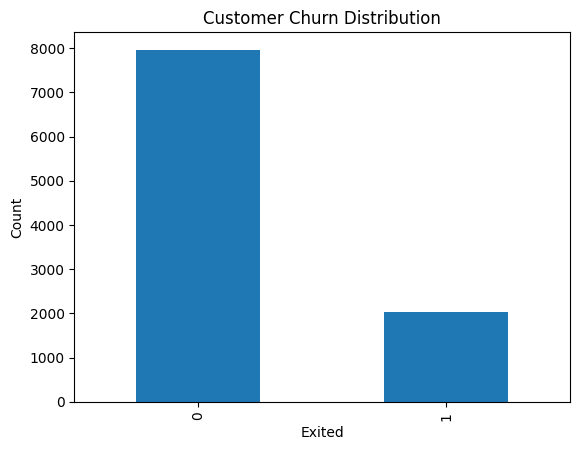

In [9]:
df["Exited"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Exited")
plt.ylabel("Count")
plt.show()

In [10]:
df.drop(["RowNumber", "CustomerId", "Surname"], axis=1, inplace=True)

In [11]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [12]:
X = df.drop("Exited", axis=1)

y = df["Exited"]

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

X["Gender"] = le.fit_transform(X["Gender"])

In [14]:
X = pd.get_dummies(X, columns=["Geography"], drop_first=True)

In [15]:
X.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,False,True


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [18]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

In [19]:
import torch

X_train = torch.tensor(X_train, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

y_test = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [20]:
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

torch.Size([12712, 11])
torch.Size([12712, 1])
torch.Size([2000, 11])
torch.Size([2000, 1])


In [21]:
import torch
import torch.nn as nn

class ChurnANN(nn.Module):
    def __init__(self, input_size):
        super(ChurnANN, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 32),
            nn.ReLU(),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)

In [22]:
input_size = X_train.shape[1]

model = ChurnANN(input_size)

print(model)

ChurnANN(
  (network): Sequential(
    (0): Linear(in_features=11, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


In [23]:
criterion = nn.BCELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [24]:
sample_output = model(X_train[:5])

print(sample_output)

tensor([[0.4822],
        [0.5293],
        [0.5103],
        [0.5001],
        [0.5079]], grad_fn=<SigmoidBackward0>)


In [25]:
# Number of epochs
epochs = 50

# Store loss for plotting
loss_history = []

for epoch in range(epochs):

    # Set model to training mode
    model.train()

    # Forward pass
    outputs = model(X_train)

    # Calculate loss
    loss = criterion(outputs, y_train)

    # Clear previous gradients
    optimizer.zero_grad()

    # Backpropagation
    loss.backward()

    # Update weights
    optimizer.step()

    # Save loss
    loss_history.append(loss.item())

    # Print every 5 epochs
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

Epoch [5/50], Loss: 0.6761
Epoch [10/50], Loss: 0.6700
Epoch [15/50], Loss: 0.6634
Epoch [20/50], Loss: 0.6562
Epoch [25/50], Loss: 0.6485
Epoch [30/50], Loss: 0.6403
Epoch [35/50], Loss: 0.6317
Epoch [40/50], Loss: 0.6228
Epoch [45/50], Loss: 0.6138
Epoch [50/50], Loss: 0.6049


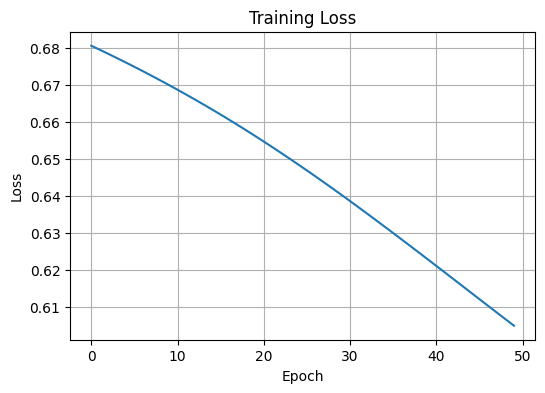

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [27]:
model.eval()

with torch.no_grad():

    predictions = model(X_test)

    predicted = (predictions >= 0.5).float()

    accuracy = (predicted == y_test).float().mean()

print(f"Test Accuracy: {accuracy.item()*100:.2f}%")

Test Accuracy: 66.90%


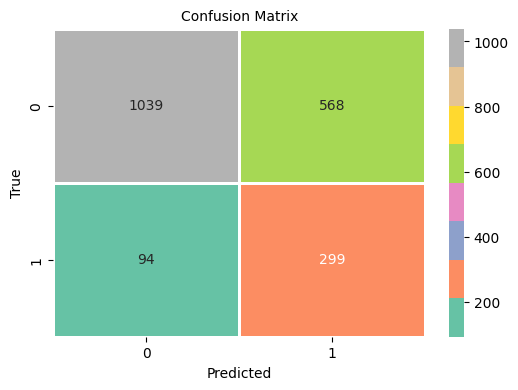

[[1039  568]
 [  94  299]]


In [32]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(
    y_test.numpy(),
    predicted.numpy()
)
class_label = [0, 1]
plt.figure(figsize=(6,4))
df_cm = pd.DataFrame(cm, index=class_label,columns=class_label)
sns.heatmap(df_cm,annot=True,cmap='Set2',linewidths=1,fmt='d')
plt.title("Confusion Matrix",fontsize=10)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print(cm)

In [33]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test.numpy(),
    predicted.numpy()
))

              precision    recall  f1-score   support

         0.0       0.92      0.65      0.76      1607
         1.0       0.34      0.76      0.47       393

    accuracy                           0.67      2000
   macro avg       0.63      0.70      0.62      2000
weighted avg       0.80      0.67      0.70      2000



In [ ]:
torch.save(model.state_dict(), "churn_ann_model.pth")

print("Model saved successfully!")

Model saved successfully!
